## Setup

In [55]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision
import torch.nn.functional as F

In [56]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [57]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

In [58]:
dataset = torchvision.datasets.MNIST("./",train = True, download=True, transform=transform)
dataset_test = torchvision.datasets.MNIST("./",train = False, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1024, shuffle=True)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=1024, shuffle=True)

In [59]:
class TwoLayerMLP(nn.Module):

    def __init__(self):
        super(TwoLayerMLP, self).__init__()

        self.lin1 = nn.Linear(28*28, 128)
        self.lin2 = nn.Linear(128, 10)
    
    def forward(self, x):

        B, C, H, W = x.shape
        
        x = x.view(B, -1)
        
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

In [60]:
model = TwoLayerMLP()

param_count = sum([p.numel() for p in model.parameters()])

print(f"Model has : {param_count/1e6} M params" )

Model has : 0.10177 M params


## Dataset distillation functions

In [ ]:
def compute_gd_step(models, images, labels, eta):

    updated_models = []
    image_tensor = torch.stack(images)
    
    for i in range(len(models)):
        curr_model = models[i]
        curr_model.train()
        
        output = curr_model(image_tensor)
        loss = F.cross_entropy(output, labels)
        
        #We need to do gradient descent by hand otherwise it won't propagate to the images

        grads = torch.autograd.grad(
            loss, 
            curr_model.parameters(), 
            create_graph=True
        )
        
        updated_params = []
        for param, grad in zip(curr_model.parameters(), grads):
            updated_params.append(param - eta * grad)
        

        updated_models.append((curr_model, updated_params))
    
    return updated_models


def eval_obj_function(test_data, test_labels, updated_models): # this is our loss function : we look at how much models improved in a single step

    criterion = nn.CrossEntropyLoss()
    loss = 0
    
    for model, updated_params in updated_models:

        output = functional_forward(model, test_data, updated_params)
        loss += criterion(output, test_labels)
    
    return loss / len(updated_models)


def functional_forward(model, x, params):
    #We need to do a forward like this to ensure gradients are propagated to the images
    B, C, H, W = x.shape
    x = x.view(B, -1)
    
    x = F.linear(x, params[0], params[1])
    x = F.relu(x)
    
    x = F.linear(x, params[2], params[3])
    
    return x

In [ ]:
#Full code to create the distilled images
def create_distilled_image(n_iter, dataloader, n_models, image_size, n_image, num_classes=10, alpha_images=1e2, alpha_eta=1e-2, prior = "none", lambda_param = 0.1, pretrained_path = None):
    
    images = []
    for _ in range(n_image):
        images.append(nn.Parameter(torch.randn(size=image_size, device=device)))
    

    if n_image % num_classes == 0:
        labels = torch.tensor([i for i in range(num_classes)] * (n_image//num_classes), device = device)
    else :
        raise ValueError("The number of images should be a multiple of the number of classes")
    
    eta = nn.Parameter(torch.tensor([2e0], device=device))
    eta_list = []
    losses_list = []
    
    if prior == "distill":
        pretrained_model = TwoLayerMLP()
        pretrained_model.load_state_dict(torch.load(pretrained_path, weights_only = False))
    
    optimizer_images = torch.optim.SGD(images, lr=alpha_images)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_images, n_iter)

    optimizer_eta = torch.optim.SGD([eta], lr=alpha_eta)


    best_loss, best_labels, best_images = torch.inf, None, None

    try :
        for k in range(n_iter):

            models = []
            for _ in range(n_models):
                mlp = TwoLayerMLP().to(device)
                models.append(mlp)

            optimizer_images.zero_grad()
            optimizer_eta.zero_grad()

            test_data, test_labels = next(iter(dataloader))

            test_data = test_data.to(device)
            test_labels = test_labels.to(device)

            updated_models = compute_gd_step(models, images, labels, eta)

            loss = eval_obj_function(test_data, test_labels, updated_models)

            if prior == "smoothness": # norm 2 penalization
                for img in images :
                    loss += lambda_param * torch.linalg.norm(torch.flatten(img), ord = 2)
            elif prior == "sparsity": # norm 1 penalization
                for img in images :
                    loss += lambda_param * torch.linalg.norm(torch.flatten(img), ord = 1)
            elif prior == "distill":
                for i in range(len(images))  :
                    
                    loss += lambda_param * nn.CrossEntropyLoss()(pretrained_model(images[i].unsqueeze(0)), torch.tensor([labels[i]])).sum() # The less accurate our pretrained model is, the bigger the loss

            loss.backward()

            optimizer_images.step()
            scheduler.step()
            optimizer_eta.step()

            eta_list.append(eta.item())
            losses_list.append(loss.item())
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_images = images
                best_labels = labels

            if k % 20 == 1:
                print(f"Iter {k}, Loss: {loss.item():.4f}, Eta: {eta.item():.4f}, Scheduler LR : {scheduler.get_last_lr()[0]:.4f}")
    except KeyboardInterrupt:
        print(f"Interrupted manually at iteration : {k}")
        return best_images, best_labels, eta_list, losses_list
            
    
    return best_images, best_labels,  eta_list, losses_list


In [ ]:
def train_on_distilled_data(images, dataloader_test, learning_rate, n_epochs, val_freq, num_classes, n_image):

    # Once we have built the distilled images with the code above,
    # we train on them to check if they actually allow the model to recognize digits
    val_accuracies = []
    if not isinstance(images, torch.Tensor):
        images = torch.stack(images)
    images = images.to(device)
    model = TwoLayerMLP().to(device)
    optimizer = torch.optim.AdamW(params = model.parameters(), lr = learning_rate)

    criterion = nn.CrossEntropyLoss()
    labels = torch.tensor([i for i in range(num_classes)] * (n_image//num_classes), device = device)
    for epoch in range(n_epochs):
 # since the number of images is very small (as little as 10), an epoch takes less than a sec !

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()


        
        if epoch%val_freq == 0 :
            val_loss = 0.0
            val_acc = 0
            for i, (data, label) in enumerate(dataloader_test) : # check validation performance
            
                data = data.to(device)
                label = label.to(device)

                output = model(data)
                val_loss += criterion(output, label).item()
    
                val_acc += (torch.argmax(output, -1) == label).sum().item()
    
            val_loss/=10000
            
            val_acc/=10000
    
            val_accuracies.append(val_acc)
    
            print(f"Epoch : {epoch}, val loss : {val_loss}, val acc : {val_acc}")
    
    return val_accuracies

### Experiment 1 : reproducing dataset distillation

In [ ]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 600, dataloader = dataloader, n_models = 200, \
                                                               image_size = (1,28,28), n_image = 10, alpha_images=1e2, alpha_eta=1e0)

Iter 1, Loss: 2.2704, Eta: 1.9654, Scheduler LR : 99.9973
Iter 21, Loss: 1.2320, Eta: 3.5827, Scheduler LR : 99.6686
Iter 41, Loss: 1.0357, Eta: 3.6908, Scheduler LR : 98.7958
Iter 61, Loss: 1.0292, Eta: 3.7029, Scheduler LR : 97.3884
Iter 81, Loss: 0.9581, Eta: 3.7454, Scheduler LR : 95.4618
Iter 101, Loss: 0.9116, Eta: 3.7800, Scheduler LR : 93.0371
Iter 121, Loss: 0.8762, Eta: 3.8488, Scheduler LR : 90.1409
Iter 141, Loss: 0.8885, Eta: 3.8910, Scheduler LR : 86.8049
Iter 161, Loss: 0.8616, Eta: 3.9415, Scheduler LR : 83.0656
Iter 181, Loss: 0.8740, Eta: 3.9678, Scheduler LR : 78.9641
Iter 201, Loss: 0.9009, Eta: 4.0169, Scheduler LR : 74.5452
Iter 221, Loss: 0.8621, Eta: 4.0819, Scheduler LR : 69.8574
Iter 241, Loss: 0.8660, Eta: 4.1432, Scheduler LR : 64.9520
Iter 261, Loss: 0.8731, Eta: 4.1663, Scheduler LR : 59.8829
Iter 281, Loss: 0.7951, Eta: 4.2363, Scheduler LR : 54.7054
Iter 301, Loss: 0.8270, Eta: 4.2961, Scheduler LR : 49.4764
Iter 321, Loss: 0.8525, Eta: 4.3193, Scheduler

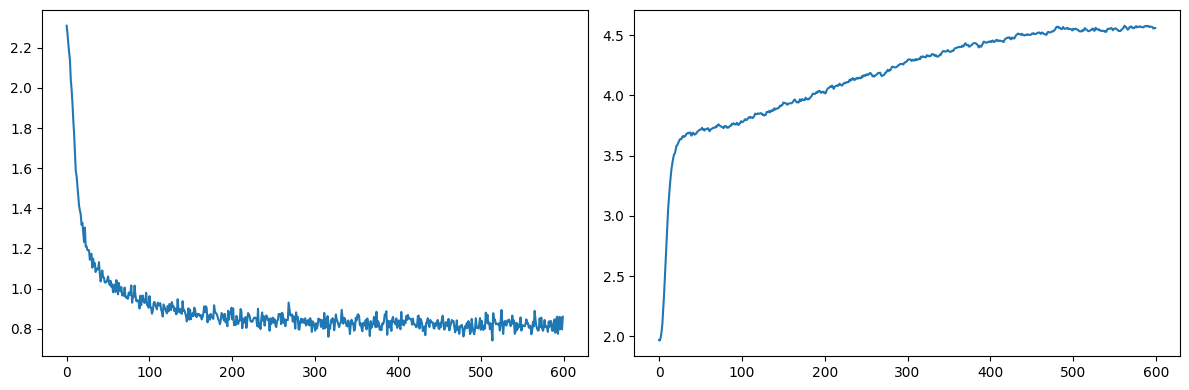

In [49]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].plot(losses_list)
axes[1].plot(np.array(torch.tensor(eta_list).detach()))
plt.tight_layout()
plt.show()

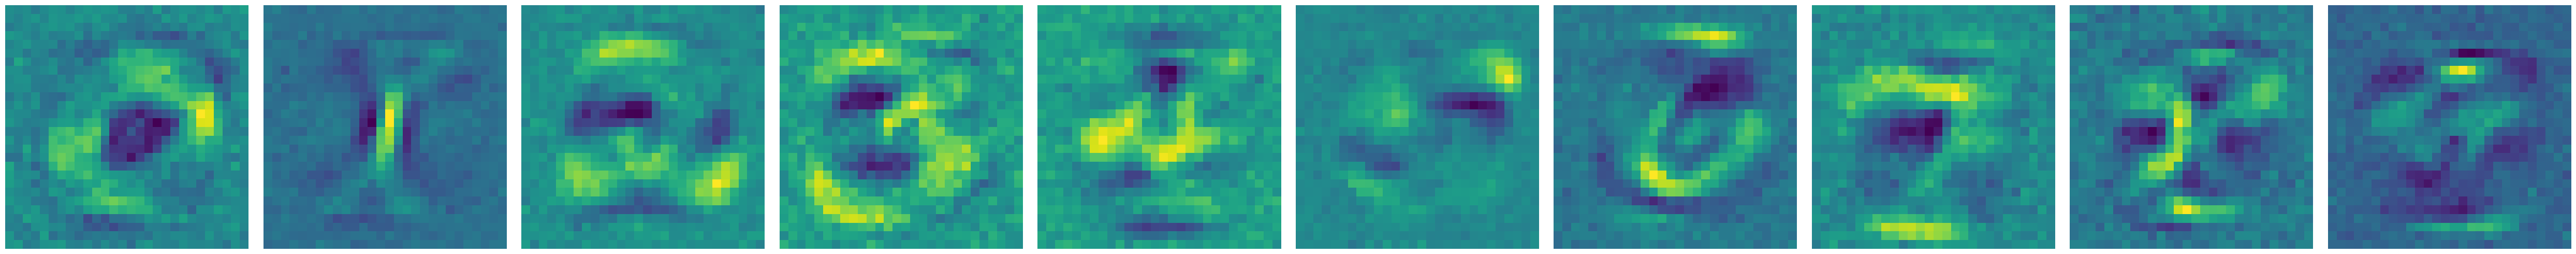

In [51]:
# Made with Claude for single row display
# Create a figure with subplots in a single row
fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))

# Handle the case where there's only one image
if len(images) == 1:
    axes = [axes]

for i in range(len(images)):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')  # Optional: hide axes

plt.tight_layout()
plt.show()

In [ ]:
val_accuracies = train_on_distilled_data(images = images, dataloader_test = dataloader_test,\
                                         learning_rate = 1e-3, n_epochs = 200, val_freq = 10, num_classes=10, n_image = 10)

Epoch : 0, val loss : 0.0022546384811401366, val acc : 0.1825
Epoch : 10, val loss : 0.0018795063138008117, val acc : 0.7743
Epoch : 20, val loss : 0.0016470348834991455, val acc : 0.8342
Epoch : 30, val loss : 0.0015447946906089784, val acc : 0.8425
Epoch : 40, val loss : 0.0015016188025474548, val acc : 0.8437
Epoch : 50, val loss : 0.0014836832165718078, val acc : 0.8448
Epoch : 60, val loss : 0.0014753198623657226, val acc : 0.8449
Epoch : 70, val loss : 0.0014714556217193604, val acc : 0.8447
Epoch : 80, val loss : 0.0014684800148010253, val acc : 0.8448
Epoch : 90, val loss : 0.0014663756370544433, val acc : 0.8446
Epoch : 100, val loss : 0.001463513219356537, val acc : 0.8447
Epoch : 110, val loss : 0.0014619279265403748, val acc : 0.8448
Epoch : 120, val loss : 0.0014601402044296264, val acc : 0.8449
Epoch : 130, val loss : 0.0014587866425514221, val acc : 0.8448
Epoch : 140, val loss : 0.0014563928127288817, val acc : 0.8448
Epoch : 150, val loss : 0.0014536173343658446, val a

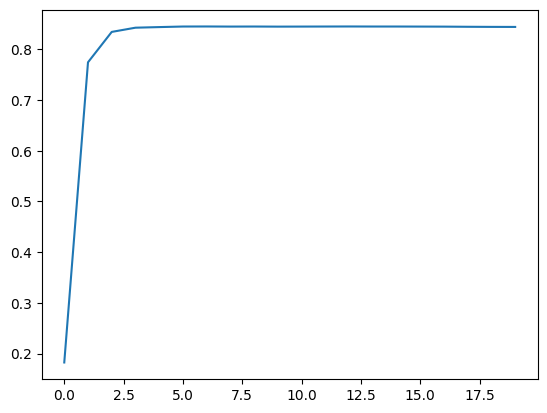

In [54]:
plt.plot(val_accuracies)
plt.show()

#### Thoughts on the reproduction

I personnally find it crazy that can we can reach 84.4% accuracy with only 10 images ! I really like visualizing the images as we see that the learned images really focus on the discriminative features of each number. For example, looking at the distilled "8", we clearly see that the image does not look a lot like a handwritten 8 but we can see very well the contrast between the two holes of the number and the rest of the image. The images look quite noisy.

### Test with 200 distilled images instead of 10

In [ ]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 2000, dataloader = dataloader,
                                                               n_models =300,
                                                               image_size = (1,28,28), n_image = 200, alpha_images=1e2, alpha_eta=1e0)

Iter 1, Loss: 2.3089, Eta: 1.9922, Scheduler LR : 99.9998
Iter 21, Loss: 2.2668, Eta: 2.1072, Scheduler LR : 99.9701
Iter 41, Loss: 2.2097, Eta: 2.5786, Scheduler LR : 99.8912
Iter 61, Loss: 2.1026, Eta: 3.3910, Scheduler LR : 99.7631
Iter 81, Loss: 1.9502, Eta: 4.4921, Scheduler LR : 99.5858
Iter 101, Loss: 1.7263, Eta: 5.6139, Scheduler LR : 99.3596
Iter 121, Loss: 1.5862, Eta: 6.3437, Scheduler LR : 99.0847
Iter 141, Loss: 1.5093, Eta: 6.6198, Scheduler LR : 98.7613
Iter 161, Loss: 1.4400, Eta: 6.6724, Scheduler LR : 98.3899
Iter 181, Loss: 1.3743, Eta: 6.6305, Scheduler LR : 97.9706
Iter 201, Loss: 1.3483, Eta: 6.5801, Scheduler LR : 97.5041
Iter 221, Loss: 1.2993, Eta: 6.5308, Scheduler LR : 96.9906
Iter 241, Loss: 1.2531, Eta: 6.5083, Scheduler LR : 96.4308
Iter 261, Loss: 1.2270, Eta: 6.4706, Scheduler LR : 95.8251
Iter 281, Loss: 1.1771, Eta: 6.4315, Scheduler LR : 95.1742
Iter 301, Loss: 1.2008, Eta: 6.4070, Scheduler LR : 94.4788
Iter 321, Loss: 1.1792, Eta: 6.3668, Scheduler

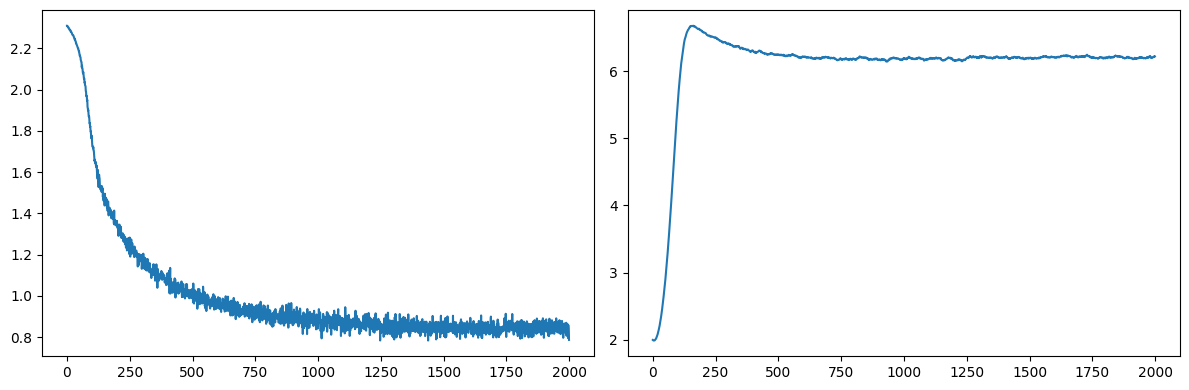

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].plot(losses_list)
axes[1].plot(np.array(torch.tensor(eta_list).detach()))
plt.tight_layout()
plt.show()

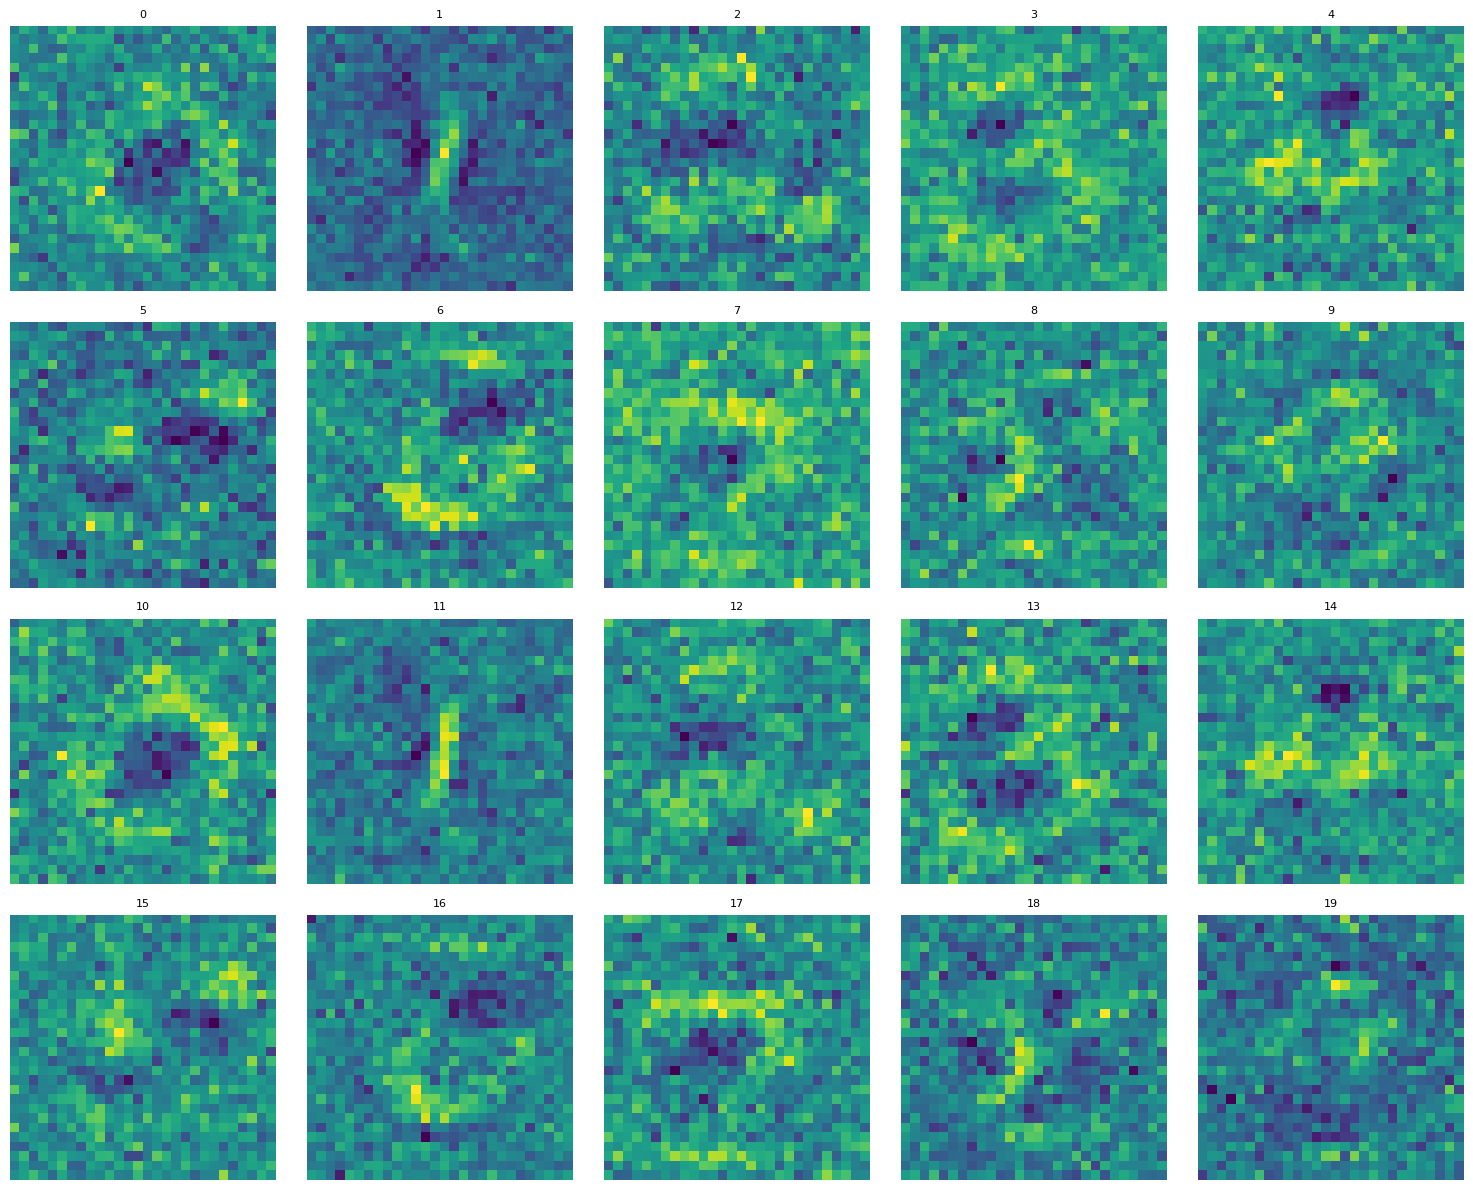

In [14]:
#Made with the help of Claude, displays the first 20 images
images_per_row = 5
rows = (20 + images_per_row - 1) // images_per_row

fig, axes = plt.subplots(rows, images_per_row, figsize=(3*images_per_row, 3*rows))
axes = axes.flatten()

for i in range(20):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')
    axes[i].set_title(f"{i}", fontsize=8)

# Hide extra subplots if images don't fill the grid
for i in range(20, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Made with Claude : visualizing the average image for each class
# labels: tensor of shape (200,) - values [0,1,2,3,4,5,6,7,8,9,0,1,...]
images = torch.stack(images)
images = images.squeeze()
num_classes = 10
H, W = images.shape[1], images.shape[2]  # image dimensions

# Reshape labels for scatter_add: (200, 1, 1) to broadcast across spatial dimensions
labels_expanded = labels.view(-1, 1, 1).expand(-1, H, W)

# Initialize tensor to accumulate sums
summed_images = torch.zeros(num_classes, H, W, dtype=images.dtype, device=images.device)

# Sum images by class
summed_images.scatter_add_(0, labels_expanded, images)

# Count images per class
counts = torch.bincount(labels, minlength=num_classes).view(num_classes, 1, 1).float()

# Compute average
averaged_images = summed_images / counts

print(f"Averaged images shape: {averaged_images.shape}")  # Should be (10, H, W)

Averaged images shape: torch.Size([10, 28, 28])


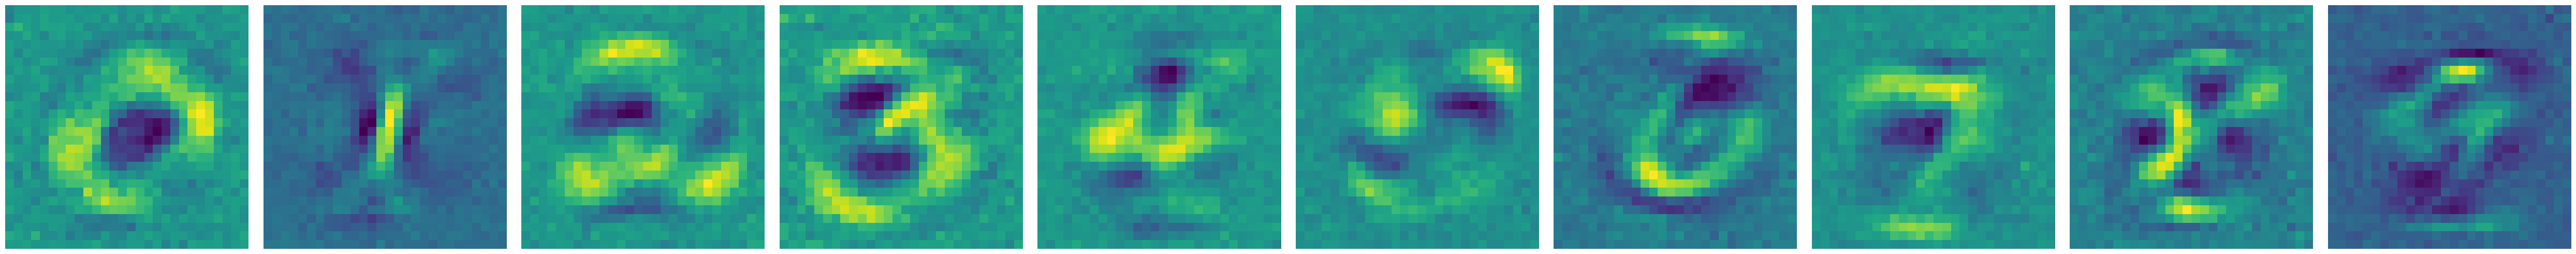

In [23]:
# Made with Claude for single row display
# Create a figure with subplots in a single row
fig, axes = plt.subplots(1, len(averaged_images), figsize=(5*len(averaged_images), 5))

# Handle the case where there's only one image
if len(averaged_images) == 1:
    axes = [axes]

for i in range(len(averaged_images)):
    axes[i].imshow(averaged_images[i].cpu().detach().numpy())
    axes[i].axis('off')  # Optional: hide axes

plt.tight_layout()
plt.show()

In [15]:
val_accuracies = train_on_distilled_data(images, dataloader_test, 1e-3, 200, 10, 10, 200)

Epoch : 0, val loss : 0.002257749104499817, val acc : 0.2181
Epoch : 10, val loss : 0.0017495909333229065, val acc : 0.8226
Epoch : 20, val loss : 0.0013600958347320556, val acc : 0.8535
Epoch : 30, val loss : 0.0011912066102027893, val acc : 0.8548
Epoch : 40, val loss : 0.001122946846485138, val acc : 0.855
Epoch : 50, val loss : 0.0010935621857643127, val acc : 0.8549
Epoch : 60, val loss : 0.001080106508731842, val acc : 0.8551
Epoch : 70, val loss : 0.0010724310755729676, val acc : 0.8551
Epoch : 80, val loss : 0.001066339063644409, val acc : 0.8555
Epoch : 90, val loss : 0.0010624436736106873, val acc : 0.8549
Epoch : 100, val loss : 0.0010592739224433898, val acc : 0.8554
Epoch : 110, val loss : 0.001053933560848236, val acc : 0.8549
Epoch : 120, val loss : 0.0010501437902450562, val acc : 0.8554
Epoch : 130, val loss : 0.0010469053983688354, val acc : 0.8555
Epoch : 140, val loss : 0.001044138491153717, val acc : 0.8554
Epoch : 150, val loss : 0.0010408545970916748, val acc : 0

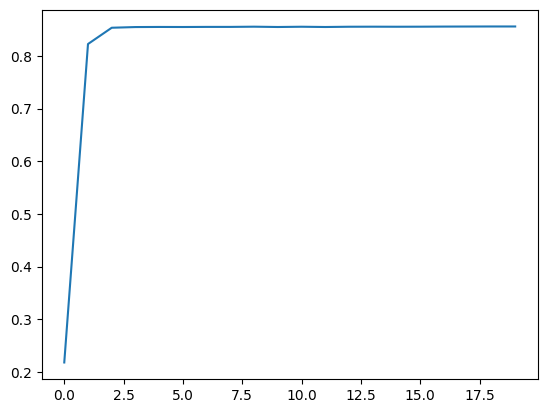

In [16]:
plt.plot(val_accuracies)
plt.show()

In [92]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 1000, dataloader = dataloader,
                                                               n_models = 30,
                                                               image_size = (1,28,28), n_image = 1000, alpha_images=1e2, alpha_eta=1e0)

Iter 1, Loss: 2.3029, Eta: 1.9984, Scheduler LR : 99.9990
Iter 21, Loss: 2.2972, Eta: 2.0208, Scheduler LR : 99.8806
Iter 41, Loss: 2.2849, Eta: 2.1203, Scheduler LR : 99.5654
Iter 61, Loss: 2.2730, Eta: 2.2843, Scheduler LR : 99.0545
Iter 81, Loss: 2.2646, Eta: 2.5224, Scheduler LR : 98.3501
Iter 101, Loss: 2.2460, Eta: 2.8305, Scheduler LR : 97.4548
Iter 121, Loss: 2.2275, Eta: 3.2039, Scheduler LR : 96.3723
Iter 141, Loss: 2.1975, Eta: 3.6446, Scheduler LR : 95.1067
Iter 161, Loss: 2.1666, Eta: 4.1422, Scheduler LR : 93.6631
Iter 181, Loss: 2.1097, Eta: 4.7004, Scheduler LR : 92.0472
Iter 201, Loss: 2.0773, Eta: 5.2804, Scheduler LR : 90.2654
Iter 221, Loss: 2.0152, Eta: 5.8524, Scheduler LR : 88.3247
Iter 241, Loss: 1.9622, Eta: 6.3996, Scheduler LR : 86.2327
Iter 261, Loss: 1.9025, Eta: 6.8786, Scheduler LR : 83.9977
Iter 281, Loss: 1.8852, Eta: 7.2913, Scheduler LR : 81.6285
Iter 301, Loss: 1.8636, Eta: 7.5643, Scheduler LR : 79.1345
Iter 321, Loss: 1.7988, Eta: 7.7274, Scheduler

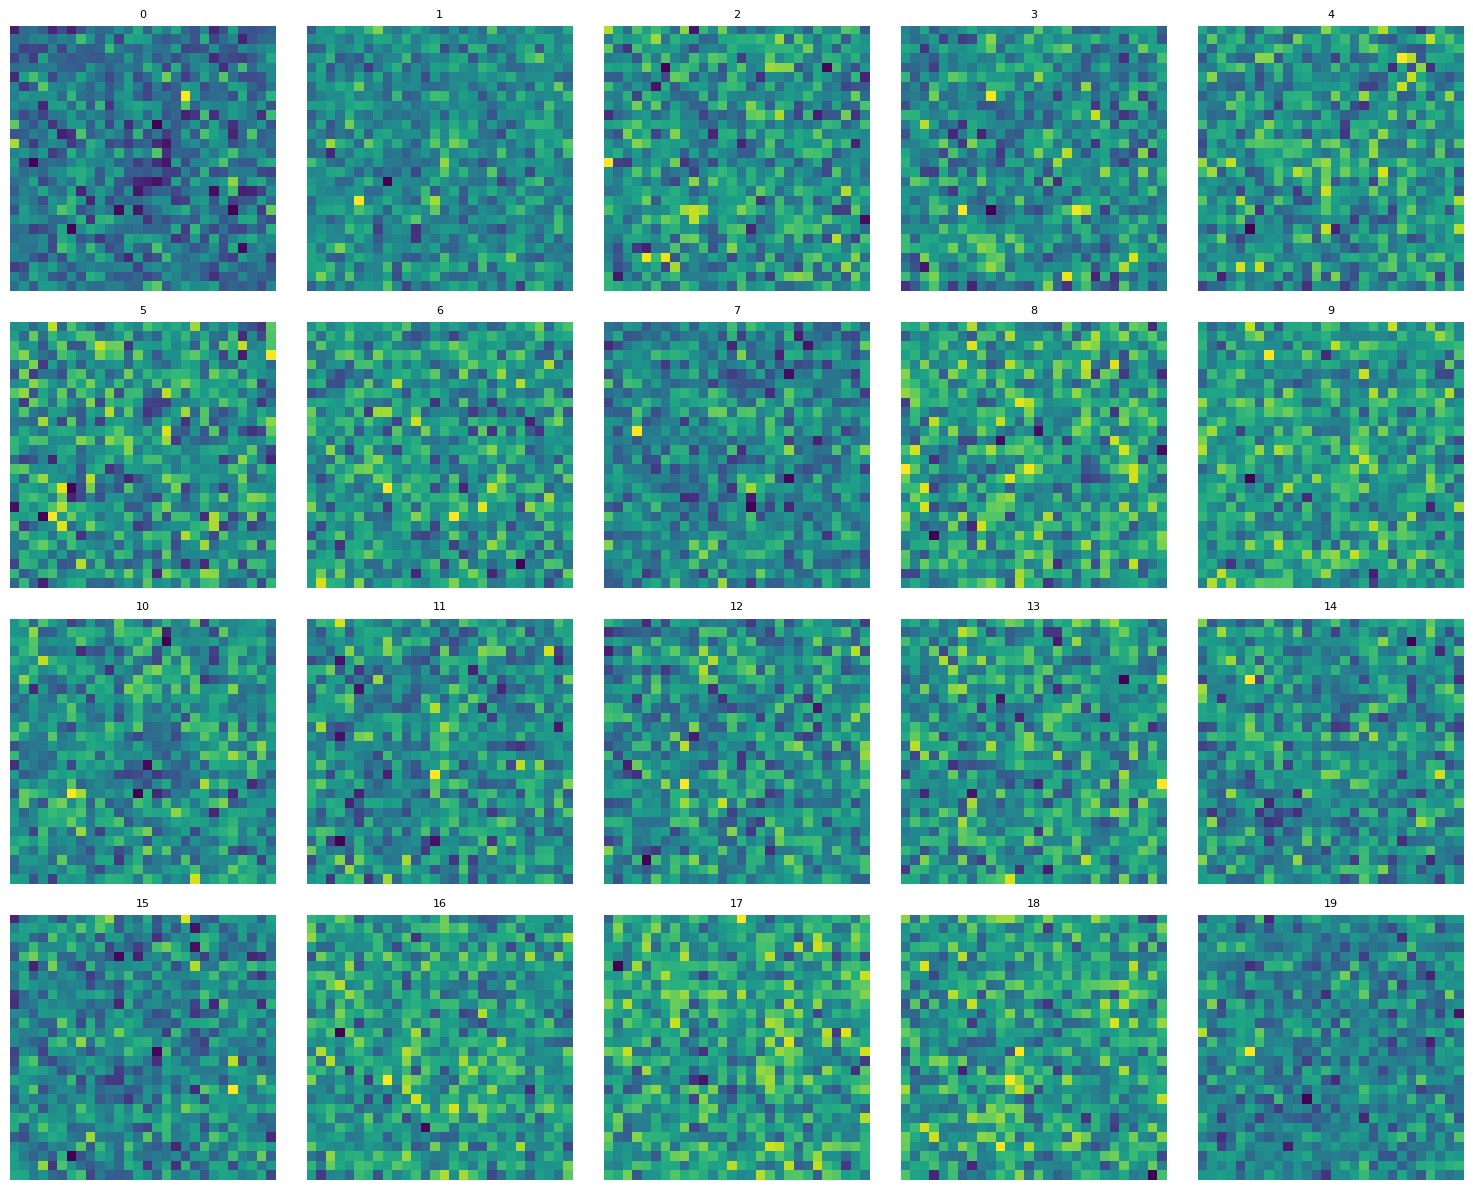

In [94]:
#Made with the help of Claude, displays the first 20 images
images_per_row = 5
rows = (20 + images_per_row - 1) // images_per_row

fig, axes = plt.subplots(rows, images_per_row, figsize=(3*images_per_row, 3*rows))
axes = axes.flatten()

for i in range(20):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')
    axes[i].set_title(f"{i}", fontsize=8)

# Hide extra subplots if images don't fill the grid
for i in range(20, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [93]:
val_accuracies = train_on_distilled_data(images = images, dataloader_test = dataloader_test, learning_rate = 1e-3, n_epochs =200, val_freq =10,num_classes = 10, n_image =1000)

Epoch : 0, val loss : 0.00225256974697113, val acc : 0.2652
Epoch : 10, val loss : 0.0017711726665496825, val acc : 0.7659
Epoch : 20, val loss : 0.001370694375038147, val acc : 0.7905
Epoch : 30, val loss : 0.0011172479271888732, val acc : 0.8067
Epoch : 40, val loss : 0.000986610984802246, val acc : 0.8111
Epoch : 50, val loss : 0.0009234152734279632, val acc : 0.8096
Epoch : 60, val loss : 0.0008895154774188996, val acc : 0.8093
Epoch : 70, val loss : 0.0008703729867935181, val acc : 0.8093
Epoch : 80, val loss : 0.0008578054666519165, val acc : 0.8095
Epoch : 90, val loss : 0.000847219580411911, val acc : 0.8092
Epoch : 100, val loss : 0.0008382739663124084, val acc : 0.8094
Epoch : 110, val loss : 0.0008306630253791809, val acc : 0.8096
Epoch : 120, val loss : 0.0008247378110885621, val acc : 0.8096
Epoch : 130, val loss : 0.0008180571019649506, val acc : 0.8098
Epoch : 140, val loss : 0.0008122045397758484, val acc : 0.81
Epoch : 150, val loss : 0.0008065738141536712, val acc : 0

#### Thoughts on scaling data

I find that the results are not as impressive as when using 10 images. Although the accuracy is better and the training is still really data efficient for 200 images, I found the images to look less informative and very noisy. It also required a lot more compute as more models and more iterations were needed to obtain the distilled images. This is shown by the fact that I was not able to scale it to 1000 images as it required way too many models to have decent images. It looks like the method does not scale very well with data, which justifies the approach I took for the next experiments. 

## 2 Can priors improve image distillation ?

This part aims at extending the paper by testing whether or not adding optimization prior helps get better accuracy.

### 2a Smoothness prior

In [ ]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 1200, dataloader = dataloader, n_models = 200,
                                                               image_size = (1,28,28), n_image = 10, alpha_images=0.5e2, alpha_eta=1e1, prior="smoothness", lambda_param=0.01)

Iter 1, Loss: 5.0513, Eta: 1.3350, Scheduler LR : 49.9997
Iter 21, Loss: 3.2544, Eta: 5.7421, Scheduler LR : 49.9585
Iter 41, Loss: 2.1667, Eta: 7.4619, Scheduler LR : 49.8490
Iter 61, Loss: 2.0801, Eta: 6.9934, Scheduler LR : 49.6714
Iter 81, Loss: 1.7900, Eta: 8.4908, Scheduler LR : 49.4261
Iter 101, Loss: 1.9281, Eta: 7.9787, Scheduler LR : 49.1139
Iter 121, Loss: 2.1318, Eta: 7.4508, Scheduler LR : 48.7356
Iter 141, Loss: 2.3637, Eta: 5.0073, Scheduler LR : 48.2923
Iter 161, Loss: 1.8607, Eta: 9.0742, Scheduler LR : 47.7851
Iter 181, Loss: 1.8184, Eta: 9.5071, Scheduler LR : 47.2154
Iter 201, Loss: 2.3973, Eta: 7.5191, Scheduler LR : 46.5849
Iter 221, Loss: 2.4599, Eta: 5.3393, Scheduler LR : 45.8952
Iter 241, Loss: 2.8304, Eta: 6.5319, Scheduler LR : 45.1482
Iter 261, Loss: 2.7078, Eta: 5.9162, Scheduler LR : 44.3460
Iter 281, Loss: 2.0156, Eta: 7.5805, Scheduler LR : 43.4908
Iter 301, Loss: 1.8898, Eta: 8.6249, Scheduler LR : 42.5849
Iter 321, Loss: 2.3527, Eta: 7.7365, Scheduler

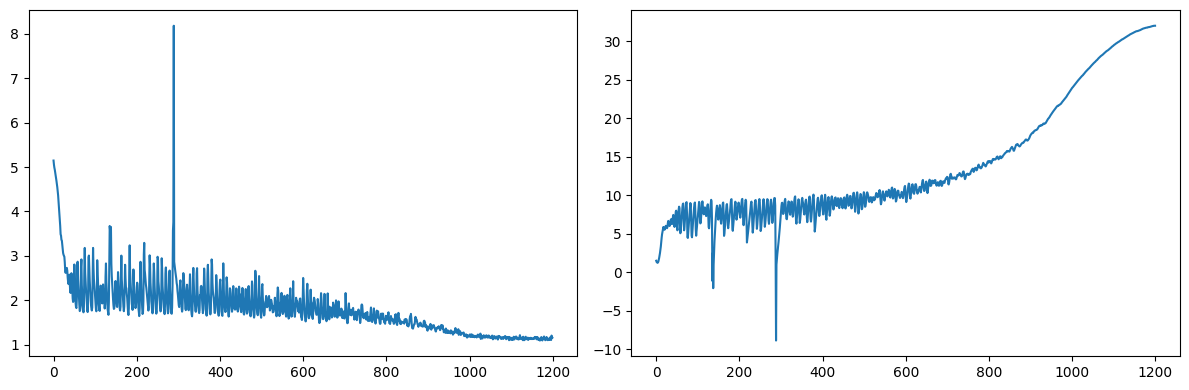

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].plot(losses_list)
axes[1].plot(np.array(torch.tensor(eta_list).detach()))
plt.tight_layout()
plt.show()

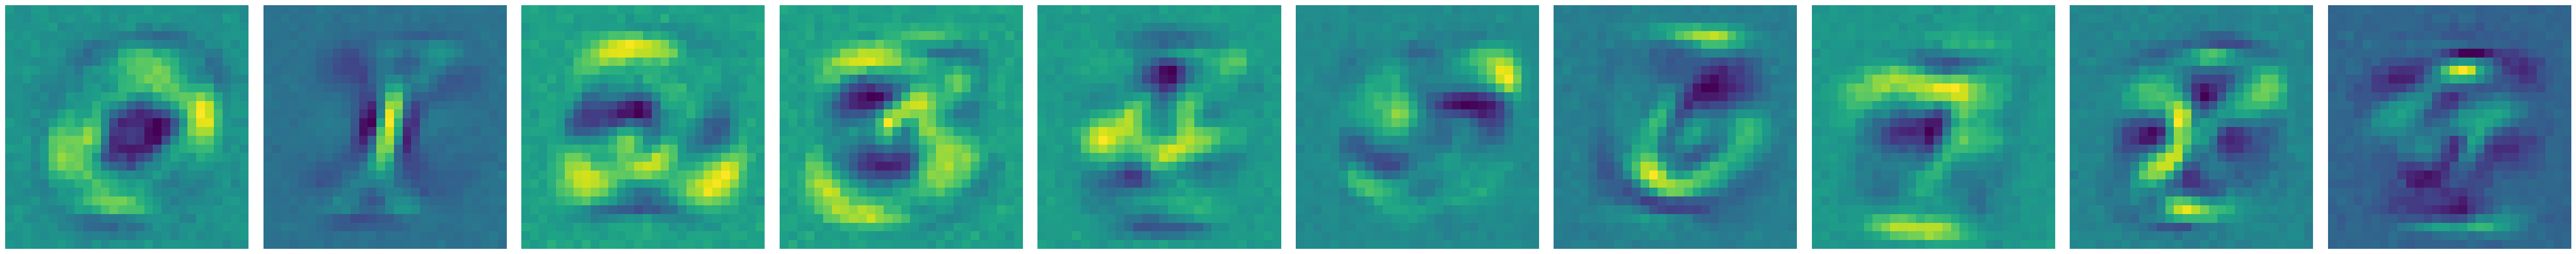

In [15]:
# Made with Claude for single row display
# Create a figure with subplots in a single row
fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))

# Handle the case where there's only one image
if len(images) == 1:
    axes = [axes]

for i in range(len(images)):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')  # Optional: hide axes

plt.tight_layout()
plt.show()

In [16]:
val_accuracies = train_on_distilled_data(images, dataloader_test, 1e-3, 400, 10, 10, 10)

Epoch : 0, val loss : 0.00225773720741272, val acc : 0.1601
Epoch : 10, val loss : 0.0018865005373954772, val acc : 0.746
Epoch : 20, val loss : 0.001446704638004303, val acc : 0.8204
Epoch : 30, val loss : 0.0010464700818061828, val acc : 0.8334
Epoch : 40, val loss : 0.0007903985798358917, val acc : 0.8344
Epoch : 50, val loss : 0.0006780482709407807, val acc : 0.8343
Epoch : 60, val loss : 0.0006308505475521088, val acc : 0.8331
Epoch : 70, val loss : 0.0006099465489387512, val acc : 0.8333
Epoch : 80, val loss : 0.0005987694025039673, val acc : 0.8333
Epoch : 90, val loss : 0.0005927145481109619, val acc : 0.8335
Epoch : 100, val loss : 0.0005887048065662384, val acc : 0.8335
Epoch : 110, val loss : 0.0005854056239128113, val acc : 0.8336
Epoch : 120, val loss : 0.0005824454486370086, val acc : 0.8341
Epoch : 130, val loss : 0.0005805078983306884, val acc : 0.8344
Epoch : 140, val loss : 0.0005783433794975281, val acc : 0.8342
Epoch : 150, val loss : 0.0005767896950244904, val acc 

#### Smoothness prior on 200 data points

In [76]:

images, labels, eta_list, losses_list = create_distilled_image(n_iter = 2000, dataloader = dataloader, n_models = 5, image_size = (1,28,28), \
                                                               n_image =200, num_classes=10, alpha_images=0.5e2, alpha_eta=1e1, \
                                                               prior="smoothness", lambda_param=0.002)

Iter 1, Loss: 13.4591, Eta: 1.9911, Scheduler LR : 49.9999
Iter 21, Loss: 12.6361, Eta: 2.8671, Scheduler LR : 49.9851
Iter 41, Loss: 11.7393, Eta: 5.3962, Scheduler LR : 49.9456
Iter 61, Loss: 10.7346, Eta: 9.2935, Scheduler LR : 49.8815
Iter 81, Loss: 9.6024, Eta: 12.0104, Scheduler LR : 49.7929
Iter 101, Loss: 8.6620, Eta: 13.4858, Scheduler LR : 49.6798
Iter 121, Loss: 7.6250, Eta: 14.5835, Scheduler LR : 49.5423
Iter 141, Loss: 6.8134, Eta: 16.3431, Scheduler LR : 49.3807
Iter 161, Loss: 5.8175, Eta: 17.7354, Scheduler LR : 49.1949
Iter 181, Loss: 5.0337, Eta: 19.5948, Scheduler LR : 48.9853
Iter 201, Loss: 4.3343, Eta: 21.2901, Scheduler LR : 48.7520
Iter 221, Loss: 3.5589, Eta: 23.3143, Scheduler LR : 48.4953
Iter 241, Loss: 3.0386, Eta: 25.4629, Scheduler LR : 48.2154
Iter 261, Loss: 2.5113, Eta: 27.5119, Scheduler LR : 47.9126
Iter 281, Loss: 2.4092, Eta: 28.8206, Scheduler LR : 47.5871
Iter 301, Loss: 2.2135, Eta: 28.7598, Scheduler LR : 47.2394
Iter 321, Loss: 2.5317, Eta: 2

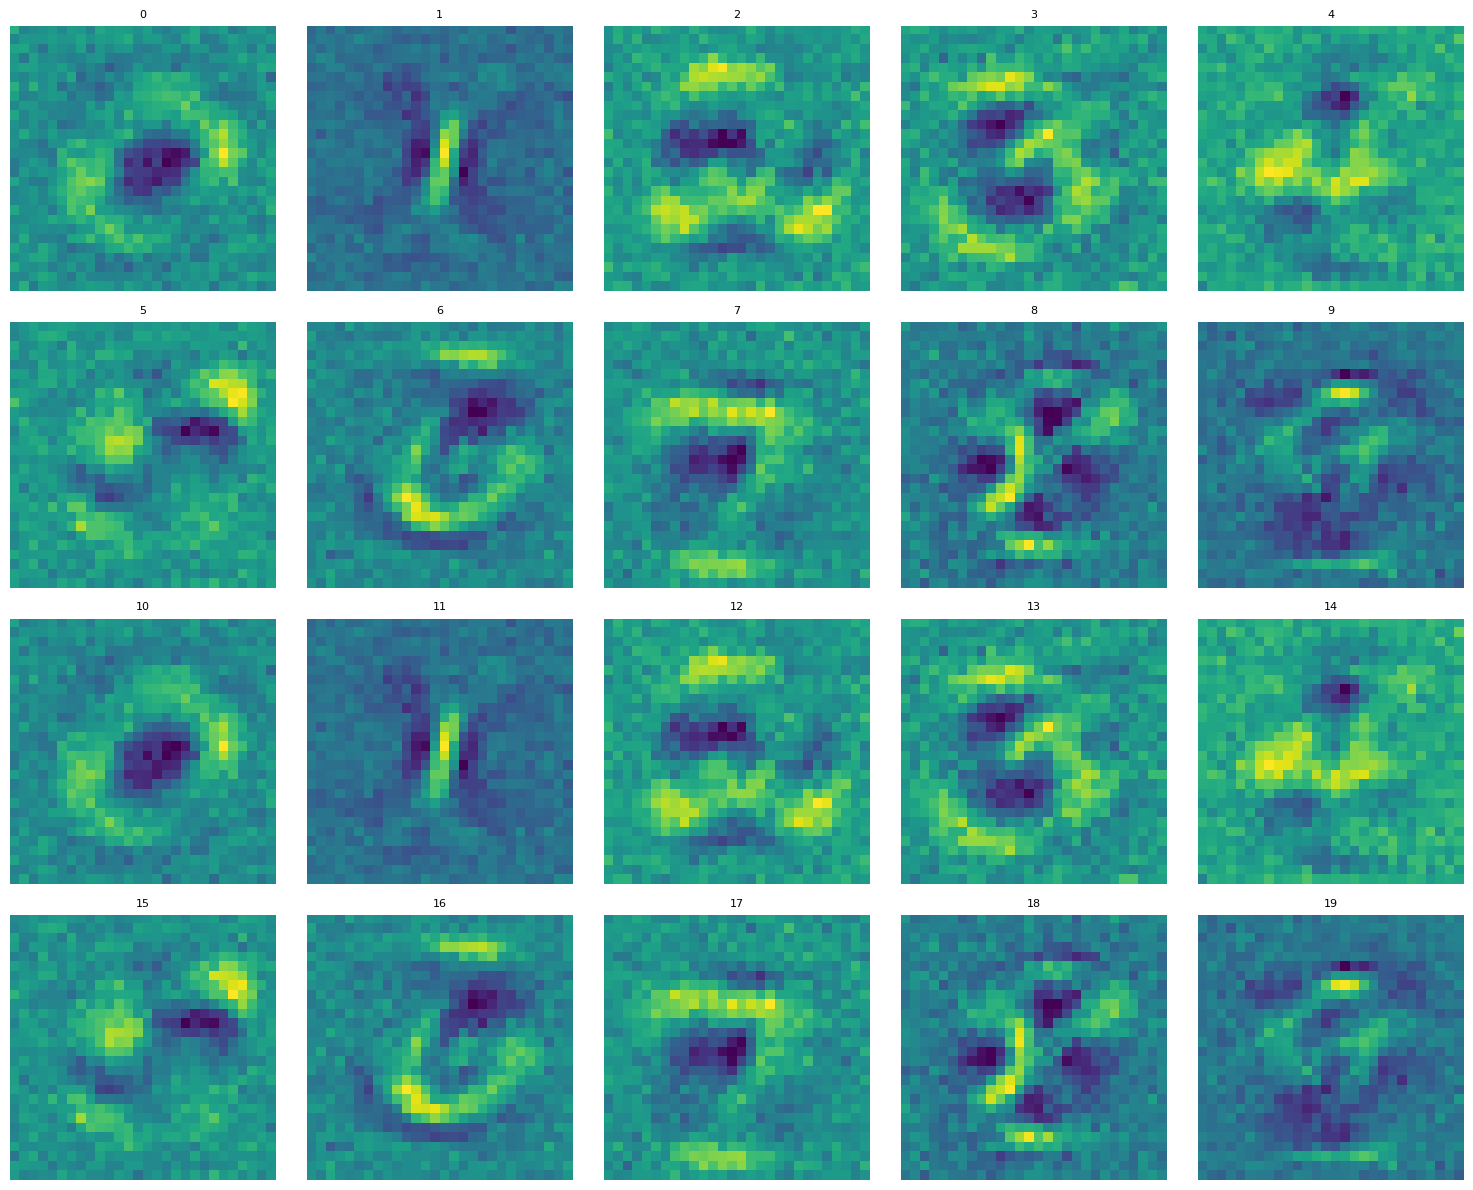

In [ ]:
#Made with the help of Claude, displays the first 20 images
images_per_row = 5
rows = (20 + images_per_row - 1) // images_per_row

fig, axes = plt.subplots(rows, images_per_row, figsize=(3*images_per_row, 3*rows))
axes = axes.flatten()

for i in range(20):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')
    axes[i].set_title(f"{i}", fontsize=8)

# Hide extra subplots if images don't fill the grid
for i in range(20, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [78]:
val_accuracies = train_on_distilled_data(images = images, dataloader_test = dataloader_test, learning_rate=1e-3,\
                                         n_epochs= 200,val_freq= 10,num_classes= 10,n_image= 200)

Epoch : 0, val loss : 0.002266422009468079, val acc : 0.2364
Epoch : 10, val loss : 0.0019421694993972778, val acc : 0.7989
Epoch : 20, val loss : 0.0015922495007514954, val acc : 0.8207
Epoch : 30, val loss : 0.001228607225418091, val acc : 0.8275
Epoch : 40, val loss : 0.0009282208740711213, val acc : 0.8316
Epoch : 50, val loss : 0.0007293439745903015, val acc : 0.8363
Epoch : 60, val loss : 0.0006222481608390808, val acc : 0.8411
Epoch : 70, val loss : 0.0005742038547992707, val acc : 0.8421
Epoch : 80, val loss : 0.0005539109826087951, val acc : 0.8419
Epoch : 90, val loss : 0.0005440164923667908, val acc : 0.8422
Epoch : 100, val loss : 0.0005390220016241073, val acc : 0.8416
Epoch : 110, val loss : 0.0005371567100286484, val acc : 0.8414
Epoch : 120, val loss : 0.0005358720541000366, val acc : 0.8413
Epoch : 130, val loss : 0.0005341961532831192, val acc : 0.8408
Epoch : 140, val loss : 0.0005335000962018967, val acc : 0.8403
Epoch : 150, val loss : 0.000535381880402565, val acc

#### Remarks on smoothness prior

Although we see qualitatively that the images are smoother, the images are not better for training. My interpretation is that the images in MNIST are not smooth at all. The values of the pixels are either zero, either relatively high due to processing. Therefore, even if we could expect some continuity in a hand-written digit, this prior does not seem to fit the dataset particularly well. We do not test with 200 images and instead look directly at the more promising sparsity prior.

### 2b Sparsity prior

In [ ]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 2000, dataloader = dataloader, \
                                                               n_models = 200, image_size = (1,28,28), n_image = 10, alpha_images=1e2, alpha_eta=1e0, prior="sparsity", lambda_param=0.00001)

Iter 1, Loss: 2.3600, Eta: 1.9542, Scheduler LR : 99.9998
Iter 21, Loss: 1.2616, Eta: 3.6158, Scheduler LR : 99.9701
Iter 41, Loss: 1.1469, Eta: 3.7329, Scheduler LR : 99.8912
Iter 61, Loss: 1.0248, Eta: 3.8223, Scheduler LR : 99.7631
Iter 81, Loss: 0.9653, Eta: 3.8863, Scheduler LR : 99.5858
Iter 101, Loss: 0.9592, Eta: 3.9742, Scheduler LR : 99.3596
Iter 121, Loss: 0.9282, Eta: 4.0606, Scheduler LR : 99.0847
Iter 141, Loss: 0.9140, Eta: 4.1114, Scheduler LR : 98.7613
Iter 161, Loss: 0.9570, Eta: 4.1730, Scheduler LR : 98.3899
Iter 181, Loss: 0.8531, Eta: 4.2939, Scheduler LR : 97.9706
Iter 201, Loss: 0.8751, Eta: 4.3427, Scheduler LR : 97.5041
Iter 221, Loss: 0.9465, Eta: 4.3778, Scheduler LR : 96.9906
Iter 241, Loss: 0.8929, Eta: 4.4811, Scheduler LR : 96.4308
Iter 261, Loss: 0.8873, Eta: 4.4956, Scheduler LR : 95.8251
Iter 281, Loss: 0.9127, Eta: 4.5422, Scheduler LR : 95.1742
Iter 301, Loss: 0.8575, Eta: 4.5990, Scheduler LR : 94.4788
Iter 321, Loss: 0.9036, Eta: 4.5496, Scheduler

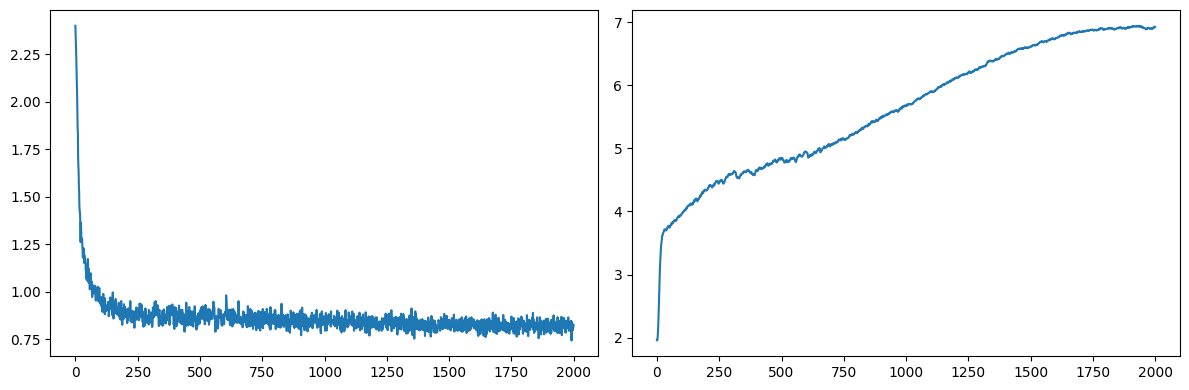

In [35]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].plot(losses_list)
axes[1].plot(np.array(torch.tensor(eta_list).detach()))
plt.tight_layout()
plt.show()

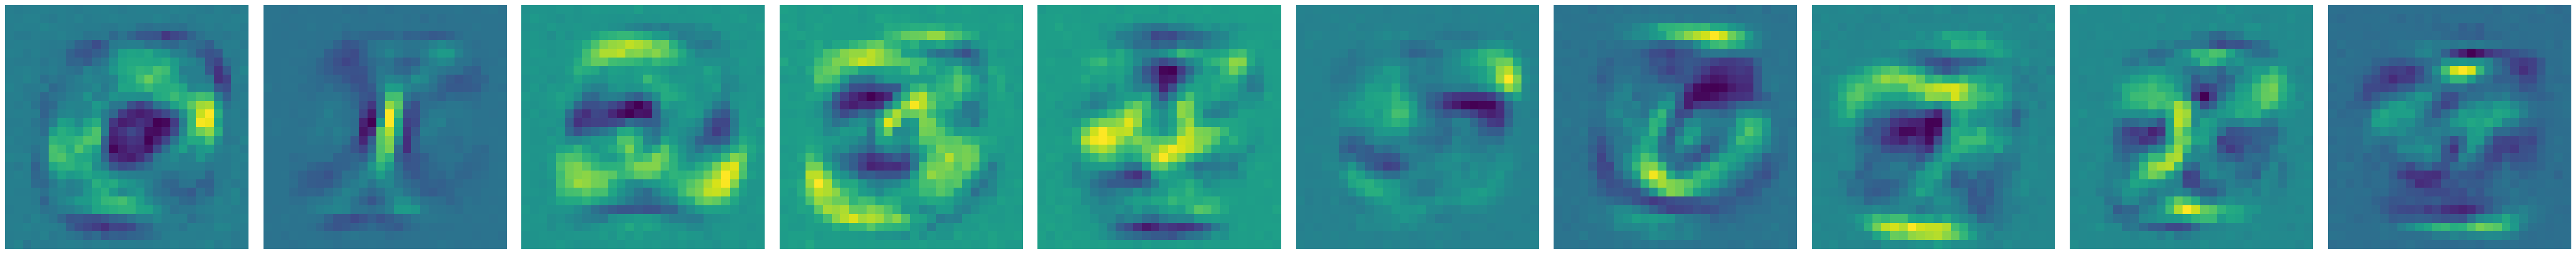

In [36]:
# Made with Claude for single row display
# Create a figure with subplots in a single row
fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))

# Handle the case where there's only one image
if len(images) == 1:
    axes = [axes]

for i in range(len(images)):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')  # Optional: hide axes

plt.tight_layout()
plt.show()

In [37]:
val_accuracies = train_on_distilled_data(images, dataloader_test, 1e-3, 200, 10, 10, 10)

Epoch : 0, val loss : 0.00227001211643219, val acc : 0.1613
Epoch : 10, val loss : 0.0018944855451583863, val acc : 0.8067
Epoch : 20, val loss : 0.0015675464987754822, val acc : 0.8295
Epoch : 30, val loss : 0.0014043907046318053, val acc : 0.8299
Epoch : 40, val loss : 0.0013330623149871827, val acc : 0.8304
Epoch : 50, val loss : 0.0013018728494644165, val acc : 0.8304
Epoch : 60, val loss : 0.001286531138420105, val acc : 0.8307
Epoch : 70, val loss : 0.0012781124591827392, val acc : 0.8314
Epoch : 80, val loss : 0.00127140154838562, val acc : 0.8316
Epoch : 90, val loss : 0.0012664489507675171, val acc : 0.8323
Epoch : 100, val loss : 0.001261847460269928, val acc : 0.8324
Epoch : 110, val loss : 0.001257163953781128, val acc : 0.833
Epoch : 120, val loss : 0.0012526604294776917, val acc : 0.8334
Epoch : 130, val loss : 0.001248670768737793, val acc : 0.8337
Epoch : 140, val loss : 0.0012434383988380432, val acc : 0.8339
Epoch : 150, val loss : 0.0012398837327957154, val acc : 0.8

In [83]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter=2000,dataloader= dataloader, n_models=10,\
                                                               image_size=(1,28,28), n_image=200, alpha_images=1e2, alpha_eta=1e0, prior="sparsity", lambda_param=0.00001)

Iter 1, Loss: 3.5451, Eta: 2.0041, Scheduler LR : 99.9998
Iter 21, Loss: 3.4716, Eta: 2.2385, Scheduler LR : 99.9701
Iter 41, Loss: 3.3669, Eta: 2.8480, Scheduler LR : 99.8912
Iter 61, Loss: 3.2171, Eta: 3.7957, Scheduler LR : 99.7631
Iter 81, Loss: 2.9799, Eta: 5.0387, Scheduler LR : 99.5858
Iter 101, Loss: 2.7610, Eta: 6.1959, Scheduler LR : 99.3596
Iter 121, Loss: 2.6006, Eta: 7.0018, Scheduler LR : 99.0847
Iter 141, Loss: 2.4004, Eta: 7.3959, Scheduler LR : 98.7613
Iter 161, Loss: 2.3833, Eta: 7.5371, Scheduler LR : 98.3899
Iter 181, Loss: 2.3092, Eta: 7.6025, Scheduler LR : 97.9706
Iter 201, Loss: 2.1633, Eta: 7.7788, Scheduler LR : 97.5041
Iter 221, Loss: 2.1139, Eta: 7.8657, Scheduler LR : 96.9906
Iter 241, Loss: 1.9723, Eta: 7.9843, Scheduler LR : 96.4308
Iter 261, Loss: 1.9270, Eta: 8.0735, Scheduler LR : 95.8251
Iter 281, Loss: 1.8766, Eta: 8.1643, Scheduler LR : 95.1742
Iter 301, Loss: 1.8759, Eta: 8.2595, Scheduler LR : 94.4788
Iter 321, Loss: 1.8172, Eta: 8.4388, Scheduler

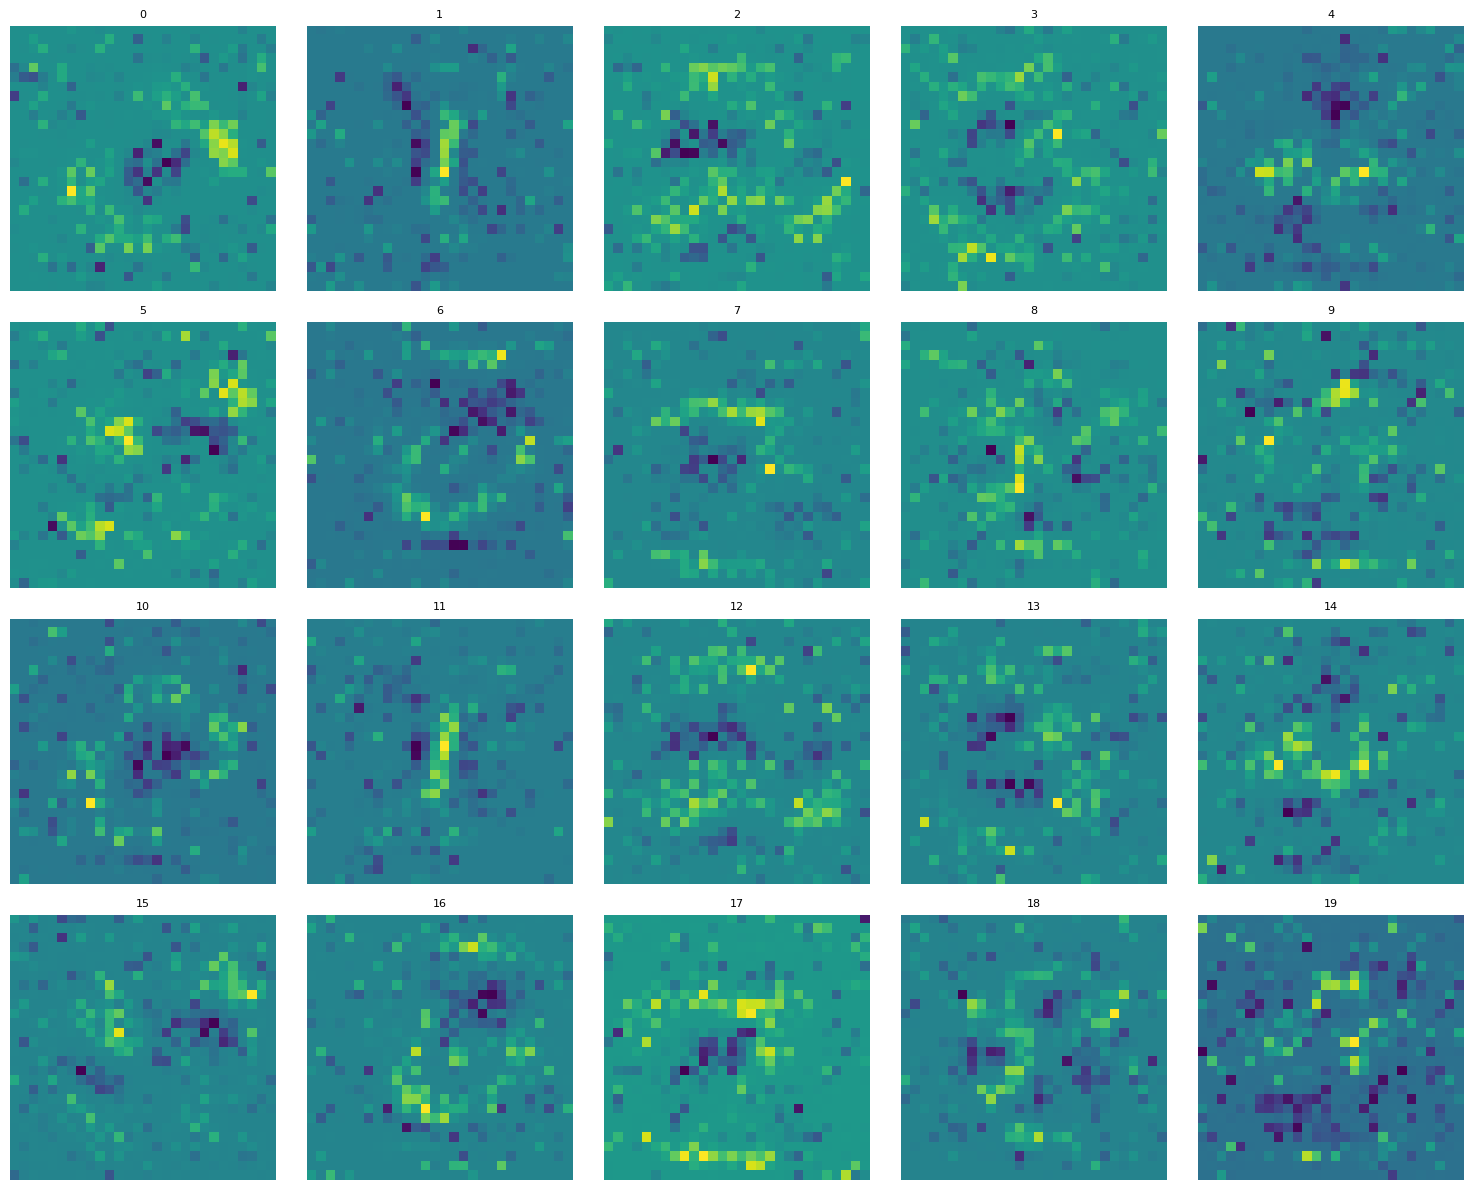

In [84]:
#Made with the help of Claude, displays the first 20 images
images_per_row = 5
rows = (20 + images_per_row - 1) // images_per_row

fig, axes = plt.subplots(rows, images_per_row, figsize=(3*images_per_row, 3*rows))
axes = axes.flatten()

for i in range(20):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')
    axes[i].set_title(f"{i}", fontsize=8)

# Hide extra subplots if images don't fill the grid
for i in range(20, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [85]:
val_accuracies = train_on_distilled_data(images = images, dataloader_test = dataloader_test, learning_rate=1e-3,\
                                         n_epochs= 200,val_freq= 10,num_classes= 10,n_image= 200)

Epoch : 0, val loss : 0.0022646878242492674, val acc : 0.1738
Epoch : 10, val loss : 0.0017983784914016724, val acc : 0.7482
Epoch : 20, val loss : 0.0012805437088012695, val acc : 0.8099
Epoch : 30, val loss : 0.0009789325952529906, val acc : 0.8359
Epoch : 40, val loss : 0.0008540628433227539, val acc : 0.8387
Epoch : 50, val loss : 0.0008032931089401246, val acc : 0.8389
Epoch : 60, val loss : 0.0007788281440734863, val acc : 0.8382
Epoch : 70, val loss : 0.0007659600853919983, val acc : 0.8376
Epoch : 80, val loss : 0.0007555282056331635, val acc : 0.8373
Epoch : 90, val loss : 0.000748516708612442, val acc : 0.8371
Epoch : 100, val loss : 0.0007417515575885772, val acc : 0.837
Epoch : 110, val loss : 0.0007363156080245971, val acc : 0.8368
Epoch : 120, val loss : 0.0007303749084472657, val acc : 0.8369
Epoch : 130, val loss : 0.000724742978811264, val acc : 0.8369
Epoch : 140, val loss : 0.0007217783689498901, val acc : 0.8367
Epoch : 150, val loss : 0.0007172768354415894, val acc

#### Thoughts on sparsity prior

The solution is indeed sparse as expected, but the pixels that are non zero are not necessarily relevant. On the 10 images experiment, we have a lot of false positive (useless pixels that are kept) and on the 200 experiment, a lot of false negative. Testing multiple regularization parameters shows that the sparsity prior works best when the parameter is almost zero, meaning we have unregularized images.

#### 2c Pretrained model prior

During the lecture, Pr Silvetti-Falls mentionned that "the best priors that are used in phone camera are learned priors". I found this very interesting and I really wanted to try it in my project. Without doing more research, I assume that the priors used for Google pixel phones must be foundation models trained on a large amount of images, like a variational autoencoder. This way the denoising tries to make the image as close to a natural image as possible. I will try to implement my own version of this idea by pushing the images to make a pretrained model confident about its predictions.

The prior belief that we are trying to model here is "Good images should be easy for a pretrained model". The way we implement this prior is by penalizing images if the pretrained model's predictions are not accurate enough.

In [ ]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 1000, dataloader =dataloader, n_models = 200,\
                                                               image_size = (1,28,28), n_image =10, alpha_images=1e2, alpha_eta=1e0,\
                                                               prior="distill", lambda_param=0.02, pretrained_path="./pretrained_model_state_dict.pt")

Iter 1, Loss: 2.5468, Eta: 1.6475, Scheduler LR : 99.9990
Iter 21, Loss: 1.7275, Eta: 1.8736, Scheduler LR : 99.8806
Iter 41, Loss: 1.3980, Eta: 2.2111, Scheduler LR : 99.5654
Iter 61, Loss: 1.2164, Eta: 2.3720, Scheduler LR : 99.0545
Iter 81, Loss: 1.1695, Eta: 2.4903, Scheduler LR : 98.3501
Iter 101, Loss: 1.0517, Eta: 2.5930, Scheduler LR : 97.4548
Iter 121, Loss: 1.0425, Eta: 2.6334, Scheduler LR : 96.3723
Iter 141, Loss: 1.0060, Eta: 2.7114, Scheduler LR : 95.1067
Iter 161, Loss: 0.9626, Eta: 2.7830, Scheduler LR : 93.6631
Iter 181, Loss: 0.9750, Eta: 2.8728, Scheduler LR : 92.0472
Iter 201, Loss: 0.9681, Eta: 2.9301, Scheduler LR : 90.2654
Iter 221, Loss: 0.9363, Eta: 3.0219, Scheduler LR : 88.3247
Iter 241, Loss: 0.9007, Eta: 3.0780, Scheduler LR : 86.2327
Iter 261, Loss: 0.9276, Eta: 3.1492, Scheduler LR : 83.9977
Iter 281, Loss: 0.8862, Eta: 3.2294, Scheduler LR : 81.6285
Iter 301, Loss: 0.8542, Eta: 3.3118, Scheduler LR : 79.1345
Iter 321, Loss: 0.8491, Eta: 3.3650, Scheduler

C:\Users\jibri\AppData\Local\Temp\ipykernel_16256\2224376865.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  axes[1].plot(np.array(torch.tensor(eta_list).detach()))


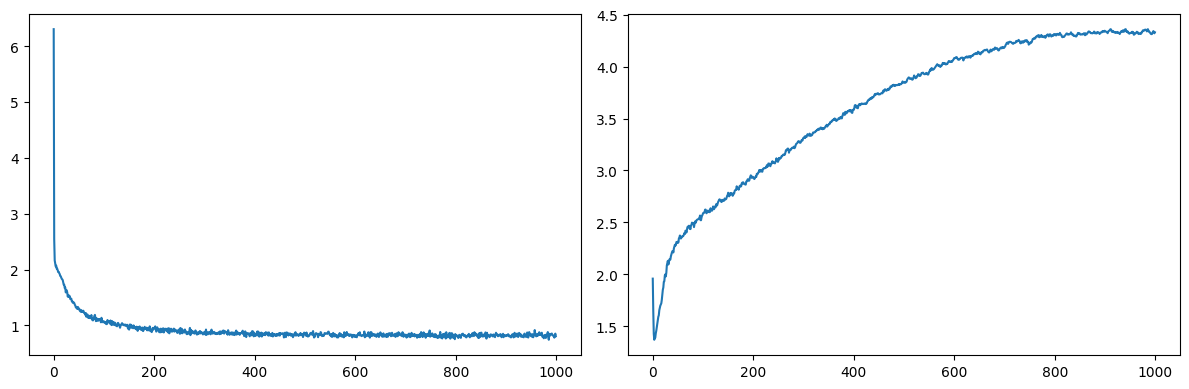

In [42]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].plot(losses_list)
axes[1].plot(np.array(torch.tensor(eta_list).detach()))
plt.tight_layout()
plt.show()

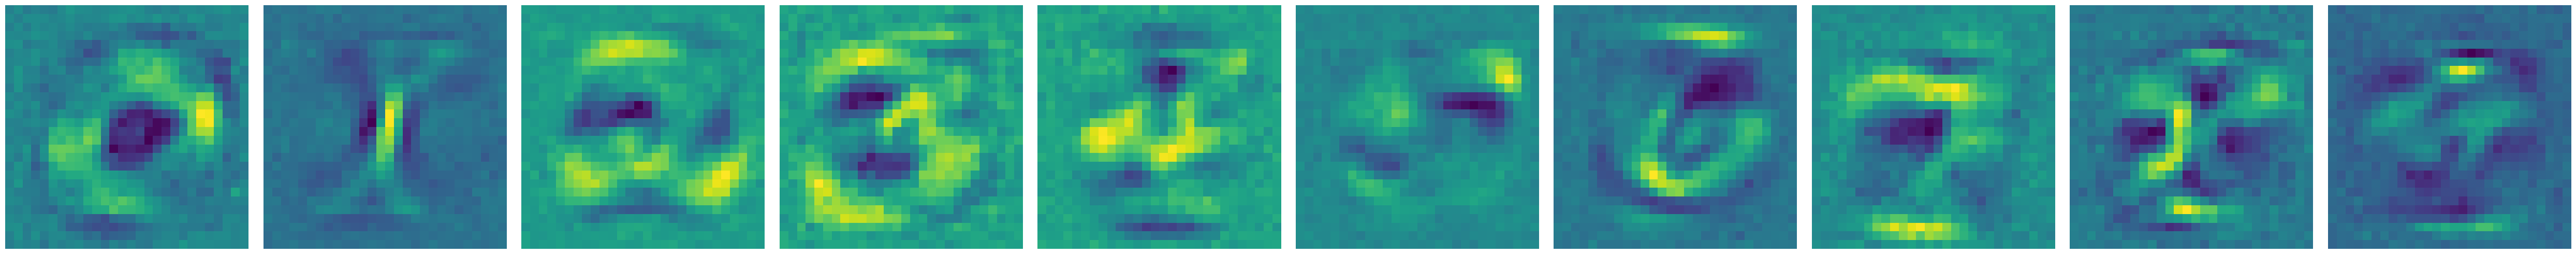

In [43]:
# Made with Claude for single row display
# Create a figure with subplots in a single row
fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))

# Handle the case where there's only one image
if len(images) == 1:
    axes = [axes]

for i in range(len(images)):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')  # Optional: hide axes

plt.tight_layout()
plt.show()

In [ ]:
val_accuracies = train_on_distilled_data(images = images, dataloader_test = dataloader_test, learning_rate =1e-3, n_epochs=200, val_freq = 10, num_classes = 10, n_image = 10)

Epoch : 0, val loss : 0.002276657485961914, val acc : 0.1793
Epoch : 10, val loss : 0.0019390812039375305, val acc : 0.7713
Epoch : 20, val loss : 0.0017174271702766418, val acc : 0.8183
Epoch : 30, val loss : 0.0016196247220039367, val acc : 0.8285
Epoch : 40, val loss : 0.001578644299507141, val acc : 0.8324
Epoch : 50, val loss : 0.0015609601378440857, val acc : 0.8332
Epoch : 60, val loss : 0.0015536520719528198, val acc : 0.8336
Epoch : 70, val loss : 0.001550492250919342, val acc : 0.8338
Epoch : 80, val loss : 0.0015481329083442687, val acc : 0.8341
Epoch : 90, val loss : 0.0015462722063064576, val acc : 0.8344
Epoch : 100, val loss : 0.0015438407421112061, val acc : 0.8346
Epoch : 110, val loss : 0.001543018627166748, val acc : 0.8345
Epoch : 120, val loss : 0.001541312849521637, val acc : 0.8349
Epoch : 130, val loss : 0.0015399168014526368, val acc : 0.8353
Epoch : 140, val loss : 0.0015370946764945983, val acc : 0.8352
Epoch : 150, val loss : 0.001535661566257477, val acc : 

In [ ]:
images, labels, eta_list, losses_list = create_distilled_image(n_iter = 700, dataloader = dataloader, n_models = 200, image_size = (1,28,28), n_image = 10,\
                                                               alpha_images=1e2, alpha_eta=1e0, prior="distill", lambda_param=0.025, pretrained_path="./pretrained_model_state_dict.pt")

Iter 1, Loss: 7.0511, Eta: 0.6941, Scheduler LR : 99.9980
Iter 21, Loss: 1.9165, Eta: 1.1737, Scheduler LR : 99.7565
Iter 41, Loss: 1.6922, Eta: 1.3773, Scheduler LR : 99.1144
Iter 61, Loss: 1.5584, Eta: 1.4530, Scheduler LR : 98.0768
Iter 81, Loss: 1.4077, Eta: 1.5664, Scheduler LR : 96.6522
Iter 101, Loss: 1.3884, Eta: 1.5806, Scheduler LR : 94.8519
Iter 121, Loss: 1.2158, Eta: 1.7041, Scheduler LR : 92.6905
Iter 141, Loss: 1.2389, Eta: 1.6990, Scheduler LR : 90.1854
Iter 161, Loss: 1.2017, Eta: 1.7625, Scheduler LR : 87.3568
Iter 181, Loss: 1.1445, Eta: 1.8359, Scheduler LR : 84.2274
Iter 201, Loss: 1.0873, Eta: 1.8784, Scheduler LR : 80.8224
Iter 221, Loss: 1.0883, Eta: 1.9228, Scheduler LR : 77.1692
Iter 241, Loss: 1.0815, Eta: 1.9460, Scheduler LR : 73.2973
Iter 261, Loss: 1.0523, Eta: 2.0087, Scheduler LR : 69.2378
Iter 281, Loss: 1.0373, Eta: 2.0649, Scheduler LR : 65.0234
Iter 301, Loss: 1.0070, Eta: 2.1274, Scheduler LR : 60.6881
Iter 321, Loss: 1.0044, Eta: 2.1627, Scheduler

C:\Users\jibri\AppData\Local\Temp\ipykernel_16256\2224376865.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  axes[1].plot(np.array(torch.tensor(eta_list).detach()))


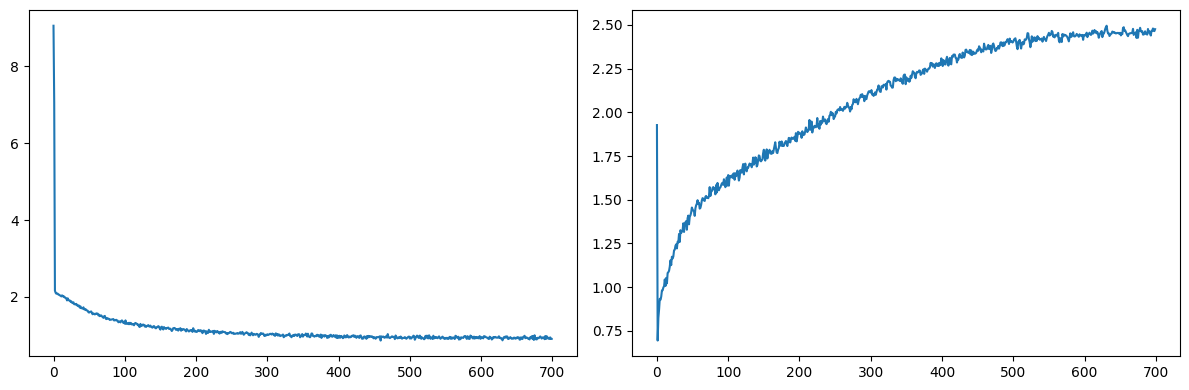

In [50]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].plot(losses_list)
axes[1].plot(np.array(torch.tensor(eta_list).detach()))
plt.tight_layout()
plt.show()

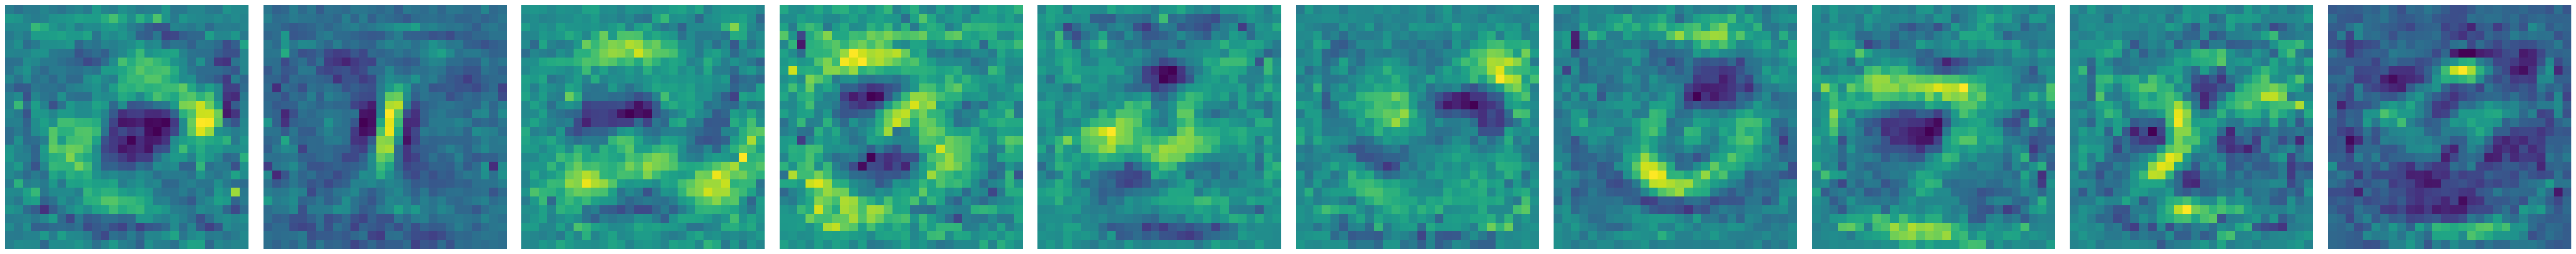

In [49]:
# Made with Claude for single row display
# Create a figure with subplots in a single row
fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))

# Handle the case where there's only one image
if len(images) == 1:
    axes = [axes]

for i in range(len(images)):
    axes[i].imshow(images[i].cpu().detach().numpy().transpose(1,2,0))
    axes[i].axis('off')  # Optional: hide axes

plt.tight_layout()
plt.show()

In [ ]:
val_accuracies = train_on_distilled_data(images = images, dataloader_test = dataloader_test, learning_rate = 1e-3,\
                                         n_epochs = 200, val_freq = 10, num_classes = 10, n_image = 10)

Epoch : 0, val loss : 0.0022689563512802123, val acc : 0.1715
Epoch : 10, val loss : 0.0019912781953811643, val acc : 0.6945
Epoch : 20, val loss : 0.0018637309670448304, val acc : 0.7579
Epoch : 30, val loss : 0.0018111889600753784, val acc : 0.7722
Epoch : 40, val loss : 0.0017904728174209595, val acc : 0.7779
Epoch : 50, val loss : 0.001781764006614685, val acc : 0.7802
Epoch : 60, val loss : 0.0017788857340812682, val acc : 0.7807
Epoch : 70, val loss : 0.0017772265791893005, val acc : 0.7809
Epoch : 80, val loss : 0.0017762333273887633, val acc : 0.781
Epoch : 90, val loss : 0.001776415729522705, val acc : 0.7809
Epoch : 100, val loss : 0.0017758215188980102, val acc : 0.7809
Epoch : 110, val loss : 0.0017749979019165039, val acc : 0.7808
Epoch : 120, val loss : 0.0017754404664039611, val acc : 0.7809
Epoch : 130, val loss : 0.0017752598404884338, val acc : 0.7808
Epoch : 140, val loss : 0.001774236798286438, val acc : 0.7808
Epoch : 150, val loss : 0.001774424946308136, val acc :

#### Thoughts on pretrained prior

While the optmization seems smoother he images don't look like they have any particular "hand-written like" features. This is probably due to the fact that, to see this foundation model effect, a model needs to have seen a lot of images, often unrelated. The fact that the digits are very noisy show that the pretrained model does not learn to denoise images, which is a key component of image foundation models. My conclusion is that this prior is mostly noise and does not help, as seen with the performances on the downstream task. I think the learned prior makes more sense in the use case mentionned in the course, as it is possible to train a very general vision model on a lot of natural images. 